# what is feature scaling

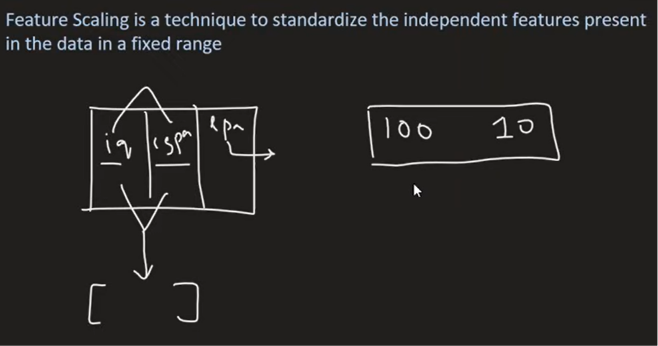

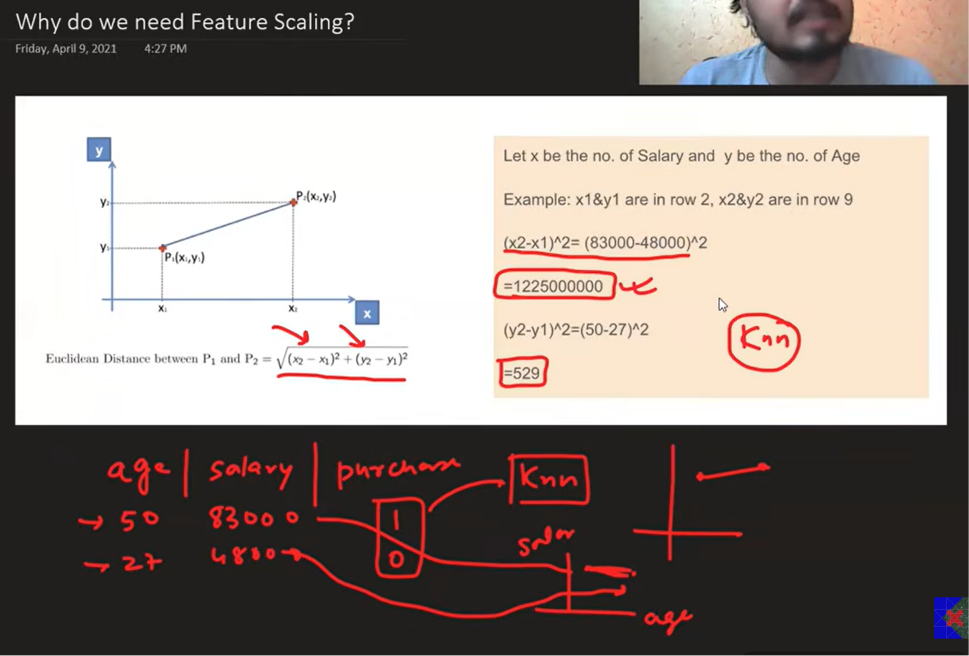

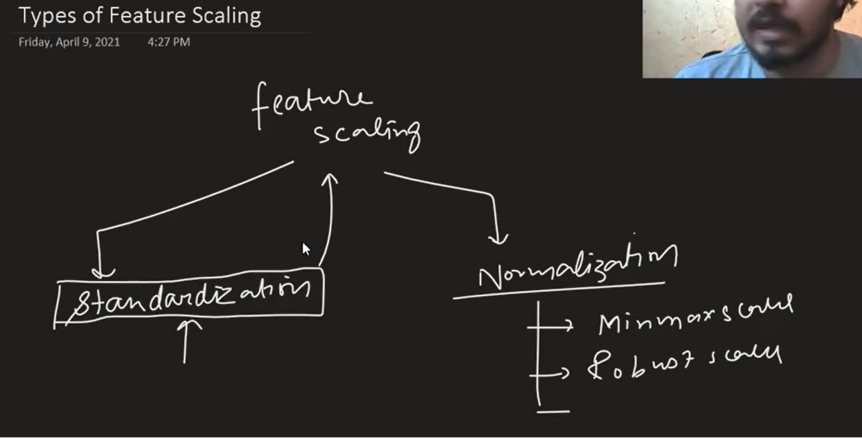

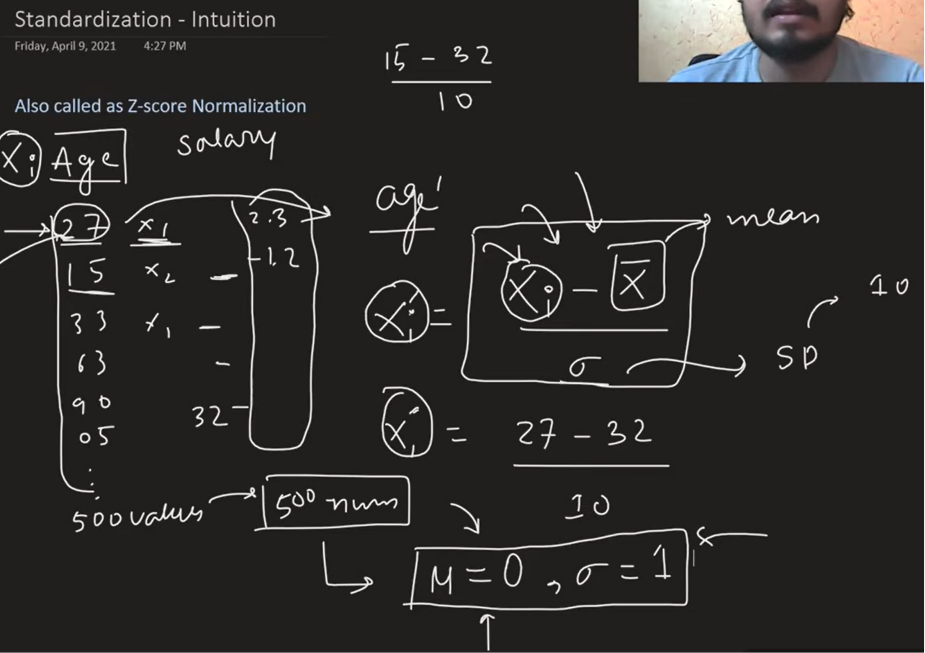

#### geometric intitution

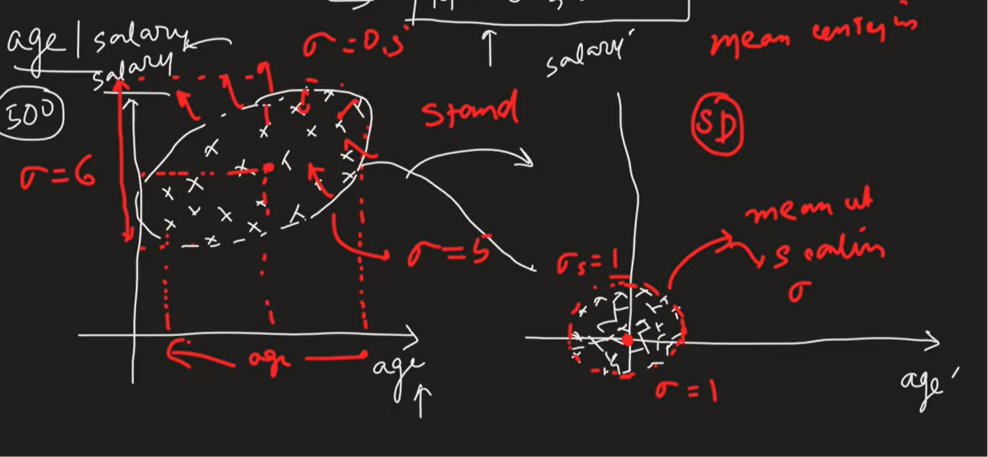

the left side graph show the distribution of data before standarization in which the x axis is age and yaxis is salary 

the mean of age and salary lie between centre which is shwon by doted and the boundary in which all datapoint are availabe is standart devaiation 


the right side graph is after the standardizattion  in which mean becomes zero and standard deviation become 1

if iniatally SD is leess than 1 then it need to be scale up and if the SD is greater than 1 then it need to be scale down 

### Example

In [4]:
import pandas as pd

In [5]:
import matplotlib.pyplot as plt

In [6]:
import numpy as np
import seaborn as sns

In [7]:
df=pd.read_csv("dataset/Social_Network_Ads.csv")

In [8]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [9]:
df=df.iloc[:,2:]

In [10]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


#### now it is better to splict your dataset before scalling

In [11]:
from sklearn.model_selection import train_test_split


In [12]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),
                                               df['Purchased'],
                                               test_size=0.3,
                                               random_state=0 
                                               )

Explanation

df.drop('Purchased', axis=1) → Removes the Purchased column from the features (X).

df['Purchased'] → Selects the Purchased column as the target (y).

test_size=0.3 → 30% of the data is used for testing.

random_state=0 → Ensures the split is reproducible.

##### here axix=1 is used becuase we have to drop  column  if we havae to remove any row then we write df.drop(1,axis=0) where 1 is index

In [13]:


x_train.shape,x_test.shape

((280, 2), (120, 2))

In [14]:
x_train.head()

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


##### lets standardize the splited data

In [15]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()


# lets store the mean and standard deviation using fit

scaler.fit(x_train) # now it calcualte the mean and SD and store in scaler object



# lets transforn the train and test datset

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

# note we always calcuale mean and sd for only xtrain but we can use that mean and sd to transform both xtrain and xtest

In [16]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

#### here there is problem we provide the df to the scaler for the standardization but it return numpy array which is deficutlt to read

In [17]:
# lets change the numpy array into dataframe

x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns) 

x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

# here columns=x_train.columns is used becuase `numpy array` doesnot have column name if we dont give the column the pandas set default column name llike 0,1,2,3....


In [18]:
x_train_scaled.head()

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


##### lets verify that mean and standard deviatioin before and after standardization 

In [19]:
x_train.describe()

,Age,EstimatedSalary
count,280.000000,280.000000
mean,37.864286,69807.142857
std,10.218201,34641.201654
min,18.000000,15000.000000
25%,30.000000,43000.000000
50%,37.000000,70500.000000
75%,46.000000,88000.000000
max,60.000000,150000.000000


In [20]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,2.800000e+02,2.800000e+02
mean,3.489272e-17,6.344132e-17
std,1.001791e+00,1.001791e+00
min,-1.947491e+00,-1.584970e+00
25%,-7.710131e-01,-7.752370e-01
50%,-8.473441e-02,2.003677e-02
75%,7.976239e-01,5.261201e-01
max,2.170181e+00,2.319101e+00


here  mean 3.489272e-17 it mean 0.00000000000000003489  which is eqal to 0	

In [21]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


### Lets see the impact of scaling

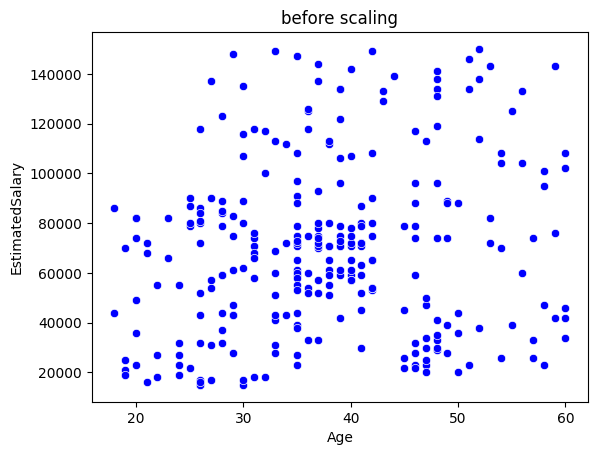

<Figure size 800x300 with 0 Axes>

In [22]:
sns.scatterplot(x=x_train['Age'],y=x_train['EstimatedSalary'],color='blue')
plt.title('before scaling')
plt.figure(figsize=(8,3))
plt.show()

#sns.scatterplot(x=x_train_scaled['Age'],y=x_train_scaled['EstimatedSalary'],color='red')

#### here figsize desnt work as the order is not correct

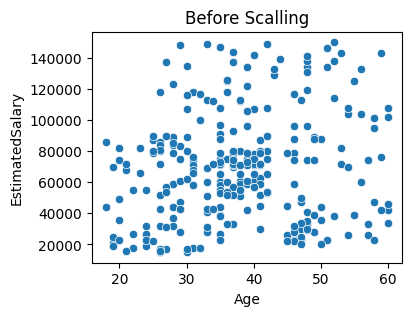

In [23]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=x_train['Age'],y=x_train['EstimatedSalary'])
plt.title('Before Scalling')
plt.show()

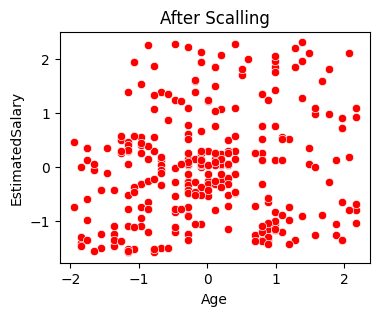

In [24]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=x_train_scaled['Age'],y=x_train_scaled['EstimatedSalary'],color='red')
plt.title("After Scalling")
plt.show()

### we wnt to plot side by side

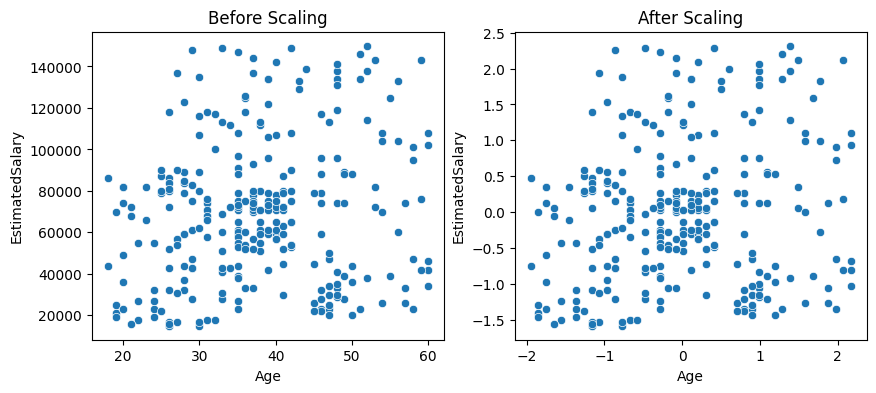

In [25]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.scatterplot(x=x_train['Age'], y=x_train['EstimatedSalary'])
plt.title("Before Scaling")

plt.subplot(1,2,2)
sns.scatterplot(x=x_train_scaled['Age'], y=x_train_scaled['EstimatedSalary'])

plt.title("After Scaling")

plt.show()

as we can see that nothing is changeed  by scaling the only change is number becomes smaller


Multiple plots (side by side)->>>>>.	plt.subplots() ✅

Single plot	    ->>>>>>>>>                plt.figure()

#### lets see another comparison 

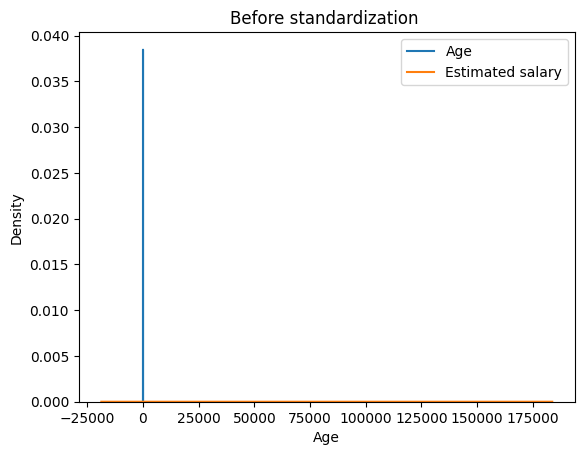

In [26]:
sns.kdeplot(x_train['Age'],label='Age')

sns.kdeplot(x_train['EstimatedSalary'],label='Estimated salary')
plt.title('Before standardization ')

plt.legend()
plt.show()


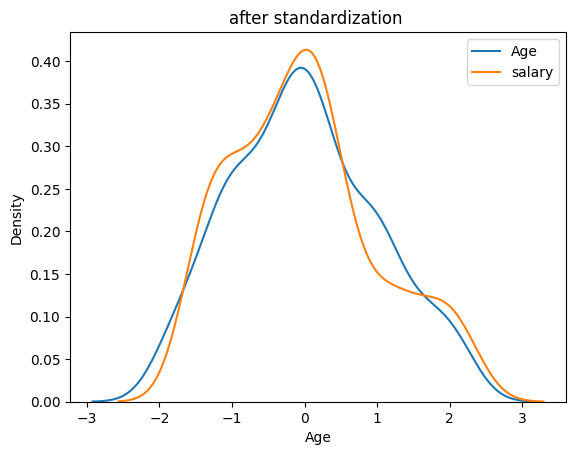

In [27]:

sns.kdeplot(x_train_scaled['Age'],label='Age')
sns.kdeplot(x_train_scaled['EstimatedSalary'],label='salary')
plt.title('after standardization ')
plt.legend()
plt.show()

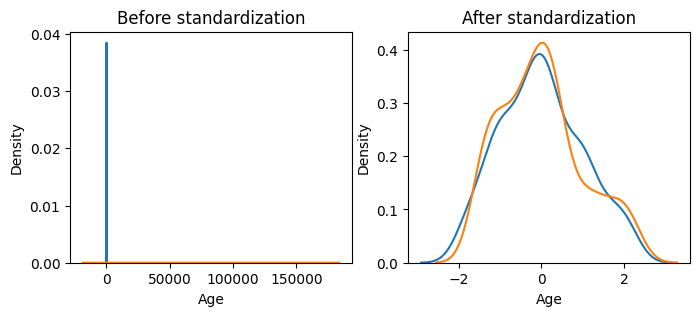

In [28]:
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
sns.kdeplot(x_train['Age'])
sns.kdeplot(x_train['EstimatedSalary'])
plt.title('Before standardization')


plt.subplot(1,2,2)
sns.kdeplot(x_train_scaled['Age'])
sns.kdeplot(x_train_scaled['EstimatedSalary'])
plt.title('After standardization')

plt.show()

as we can see that before standardization nothig understadn


### comparsion of distribution 

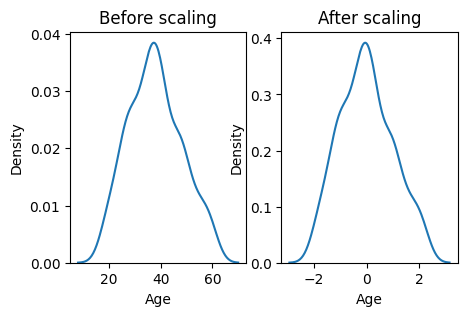

In [29]:
plt.figure(figsize=(5,3))
plt.subplot(1,2,1)
sns.kdeplot(x_train['Age'])
plt.title('Before scaling')

plt.subplot(1,2,2)
sns.kdeplot(x_train_scaled['Age'])
plt.title("After scaling")

plt.show()


as we see even after scallign distributio is same

### Why Scalling is Important?

In [30]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()
model_scaled=LogisticRegression()


In [31]:
model.fit(x_train,y_train)
model_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [32]:
prediction=model.predict(x_test)
Scaled_predict=model_scaled.predict(x_test_scaled)


In [33]:
from sklearn.metrics import accuracy_score

print("Actual Accuracy: ",accuracy_score(y_test,prediction) )
print("Scaled Accuracy: ",accuracy_score(y_test,Scaled_predict))

Actual Accuracy:  0.875
Scaled Accuracy:  0.8666666666666667


#### in above observatioon  output is slightly differnt because in case  o logistic regressioin algo scalled value of more accuracy it mena sthe logisctic regression algo work beetter with scalled data

### lets take an example of decision tree algo

this algo is not affected by scalled or not scalled data but if scalled data is provided then it is better

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()


In [37]:
dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
dt_pred=dt.predict(x_test)
dt_pred_scaled=dt_scaled.predict(x_test_scaled)

In [39]:
from sklearn.metrics import accuracy_score

print("actual score: ",accuracy_score(y_test,dt_pred) )
print("scaled_model_score: ",accuracy_score(y_test,dt_pred_scaled))

actual score:  0.875
scaled_model_score:  0.8666666666666667


#### in decison tree there is no significanse of scaled data

## Effect of outlier

In [56]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


as we can see that the min age and salary is  15 adn 15k while the max age and salary is 60 and 150k

### lets put some outlier by own see what happpen

In [ ]:
df=df.append(pd.DataFrame({'Age':[5,85,95],'EstimatedSalary':[500,300000,250000],'Purchased':[0,1,1]}))

AttributeError: 'DataFrame' object has no attribute 'append'

in recent version df.append() is no longer avilable instead of this `concat is used`

In [61]:
new_row=pd.DataFrame({'Age':[5,85,90],'EstimatedSalary':[500,250000,300000],'Purchased':[0,1,2]})

In [62]:
new_row

,Age,EstimatedSalary,Purchased
0,5,500,0
1,85,250000,1
2,90,300000,2


In [63]:
nwdf=pd.concat([df,new_row])

In [64]:
nwdf

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
0,5,500,0
1,85,250000,1


as we see at the end of df the indexing start from 0 to keep index continue we use `ignore_index=true`

In [67]:
df=pd.concat([df,new_row],ignore_index=True)

In [69]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,85,250000,1
402,90,300000,2
403,5,500,0
404,85,250000,1


lets split our data and scaled it

In [74]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),
                                               df['Purchased'],
                                               test_size=0.1,
                                               random_state=0
                                               
                                               )

In [76]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((365, 2), (41, 2), (365,), (41,))

#### lets scale this

In [79]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaler.fit(x_train)

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)



lets converst the nupmy array into dataframe

In [83]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [85]:
x_train_scaled.head(),x_test_scaled.head()

(        Age  EstimatedSalary
 0 -1.043351        -0.888231
 1  1.253327         0.816158
 2 -1.043351        -1.011738
 3 -0.958289         0.322132
 4 -0.277792        -1.258751,
         Age  EstimatedSalary
 0 -1.298538        -1.061140
 1  1.253327         1.779508
 2 -0.958289        -1.258751
 3  0.062457        -0.715322
 4 -0.873227        -0.394206)

lets see the by scatter plot

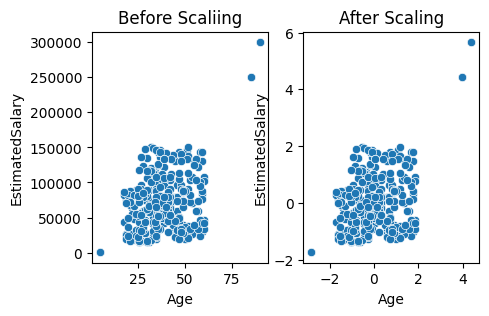

In [94]:
plt.figure(figsize=(5,3))
plt.subplot(1,2,1)
sns.scatterplot(x=x_train['Age'],y=x_train['EstimatedSalary'])
plt.title('Before Scaliing')

plt.subplot(1,2,2)
sns.scatterplot(x=x_train_scaled['Age'],y=x_train_scaled['EstimatedSalary'])
plt.title('After Scaling')

plt.show()

as we see there is no change in outliers even after scaling hence outliers should be handle seperately

### when to use scaling

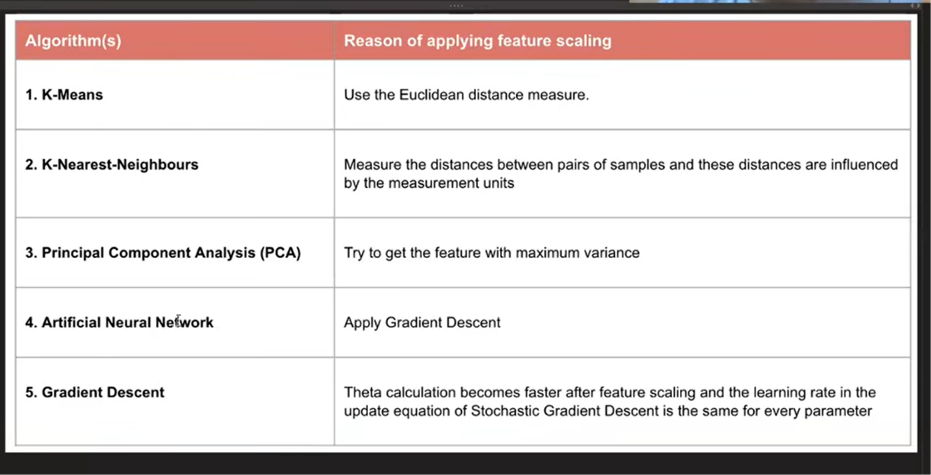